# CosMx Pancreas data visualizations

- Cell type composition

In [1]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [3]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

In [6]:
import scanpy as sc
import squidpy as sq

/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.

## Figure setting

In [13]:
import yaml
import matplotlib.pyplot as plt

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"]["melton25"]

## Load data

In [7]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, 'data', 'melton25.h5ad'))
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

## Cell type composition

/tmp/ipykernel_2784872/2543287361.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby(['condition', 'cell_type_coarse']).size().unstack(fill_value=0)


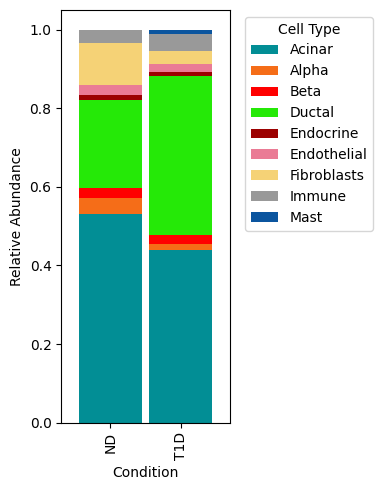

In [21]:
# Step 1: Group observations by 'condition' and count each 'CellTypes_max' entry
counts = adata.obs.groupby(['condition', 'cell_type_coarse']).size().unstack(fill_value=0)

# Step 2: Calculate relative abundance (proportion) by normalizing counts within each condition
relative_abundance = counts.div(counts.sum(axis=1), axis=0)

#colors = adata.uns['Niche_label_colors']

# Step 3: Plot stacked bar plot
relative_abundance.plot(kind='bar', stacked=True, color=CELL_TYPE_COLORS, figsize=(4, 5),width=0.9)

# Add labels and title
plt.xlabel('Condition')
plt.ylabel('Relative Abundance')
#plt.title('Relative Abundance of Cell Types by Condition')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{project_root}/figures/{DATA}/data_visualization/cell_type_relative_abundance_per_condition.png", format="png", bbox_inches="tight", dpi=1200)
plt.show()